In [1]:
#!pip install -U dhlab
import os 
import datetime as dt
import pandas as pd

import dhlab as dh
from digital_tekstanalyse.sentiment import load_corpus_from_file, compute_sentiment_analysis, add_urls

In [2]:
# INPUT KREVES
word = "biblioteket"    # Nøkkelord som skal forekomme i tekstene

In [3]:
# INPUT KREVES
file_path = "FYLL INN"

In [4]:
# INPUT KREVES
city="Kristiansand"     # Publiseringssted for avisene
from_year=2000          # Start for tidsperiode det søkes i
to_year=2022            # Slutt for tidsperiode
number_of_docs=10000    # Maks antall dokumenter i tekstutvalget

In [5]:
# corpus-variabelen peker til korpusdefinisjonen, som et dhlab.Corpus-objekt

if os.path.exists(file_path):
    corpus = load_corpus_from_file(file_path)

    print("Lastet corpus fra fil: ", file_path)
else:
    corpus = dh.Corpus(
        doctype="digavis", 
        fulltext=word, 
        freetext=f"city: {city}",
        from_year=from_year,
        to_year = to_year,
        limit=number_of_docs
    )

    print("Lastet corpus fra parametere: ")
    print(f"Aviser, utgitt mellom {from_year} og {to_year} i {city}, der ordet \"{word}\" forekommer.")

print(f"corpus består av {corpus.size} utgivelser")


Lastet corpus fra parametere: 
Aviser, utgitt mellom 2000 og 2022 i Kristiansand, der ordet "biblioteket" forekommer.
corpus består av 3441 utgivelser


In [6]:
# INPUT KREVES
save_to_file=False       # Hvorvidt tekstutvalget skal lagres som CSV-fil, til senere bruk

if save_to_file:
    new_file_path = f"corpus_avis_{corpus.frame.year.min()}_{corpus.frame.year.max()}_{city}_{word}_created{dt.date.today()}.csv"
    corpus.to_csv(new_file_path)

In [7]:
# Beregn en sentimentscore til kontekstene der nøkkelordet forekommer.
result = compute_sentiment_analysis(corpus, word)

In [8]:
result.head()


,dhlabid,urn,title,city,timestamp,year,doctype,word,count,positive,negative,sentimentscore
0,200272198,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20111102,2011,digavis,biblioteket,2,1,0,1
1,200272198,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20111102,2011,digavis,biblioteket,2,1,0,1
2,200272134,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20100728,2010,digavis,biblioteket,2,1,0,1
3,200272134,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20100728,2010,digavis,biblioteket,2,1,1,0
4,200272116,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20100317,2010,digavis,biblioteket,1,0,0,0


In [9]:
row_number = 1  # Endre radnummeret etter eget ønske

result = add_urls(result)
print(result.url[row_number])

https://www.nb.no/items/URN:NBN:no-nb_digavis_budstikkasoegne_null_null_20111102_13_44_1?searchText=biblioteket


In [10]:
result

,dhlabid,urn,title,city,timestamp,year,doctype,word,count,positive,negative,sentimentscore,url
0,200272198,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20111102,2011,digavis,biblioteket,2,1,0,1,https://www.nb.no/items/URN:NBN:no-nb_digavis_...
1,200272198,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20111102,2011,digavis,biblioteket,2,1,0,1,https://www.nb.no/items/URN:NBN:no-nb_digavis_...
2,200272134,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20100728,2010,digavis,biblioteket,2,1,0,1,https://www.nb.no/items/URN:NBN:no-nb_digavis_...
3,200272134,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20100728,2010,digavis,biblioteket,2,1,1,0,https://www.nb.no/items/URN:NBN:no-nb_digavis_...
4,200272116,URN:NBN:no-nb_digavis_budstikkasoegne_null_nul...,budstikkasoegne,Kristiansand,20100317,2010,digavis,biblioteket,1,0,0,0,https://www.nb.no/items/URN:NBN:no-nb_digavis_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5577,200484782,URN:NBN:no-nb_digavis_faedrelandsvennen_null_n...,faedrelandsvennen,Kristiansand,20120607,2012,digavis,biblioteket,3,4,0,4,https://www.nb.no/items/URN:NBN:no-nb_digavis_...
5578,200484782,URN:NBN:no-nb_digavis_faedrelandsvennen_null_n...,faedrelandsvennen,Kristiansand,20120607,2012,digavis,biblioteket,3,2,1,1,https://www.nb.no/items/URN:NBN:no-nb_digavis_...
5579,200484782,URN:NBN:no-nb_digavis_faedrelandsvennen_null_n...,faedrelandsvennen,Kristiansand,20120607,2012,digavis,biblioteket,3,0,0,0,https://www.nb.no/items/URN:NBN:no-nb_digavis_...
5580,200483223,URN:NBN:no-nb_digavis_faedrelandsvennen_null_n...,faedrelandsvennen,Kristiansand,20030405,2003,digavis,biblioteket,1,2,0,2,https://www.nb.no/items/URN:NBN:no-nb_digavis_...


<Axes: xlabel='year'>

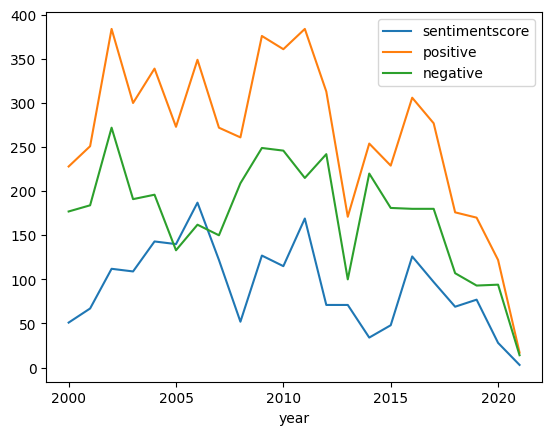

In [11]:
r = result[["year","positive", "negative", "sentimentscore"]]
rgroup = r.groupby("year")[["sentimentscore", "positive", "negative"]].sum() 
rgroup.plot()

In [12]:
outputfile = f"sentimentanalyse_aviskorpus_{from_year}-{to_year}_{dt.date.today()}.csv"
result.to_csv(outputfile)